In [1]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
x=[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=[['Outcome']]

In [10]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [13]:
x.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [14]:
y.columns

AttributeError: 'Series' object has no attribute 'columns'

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [19]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [20]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [21]:
diff=pd.DataFrame({"Actul":y_test,"Predicted":prediction})
diff

,Actul,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [23]:
diff.to_csv('diabetes_data.csv')

In [26]:
diff.to_excel('diabetes_data.xlsx')

In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


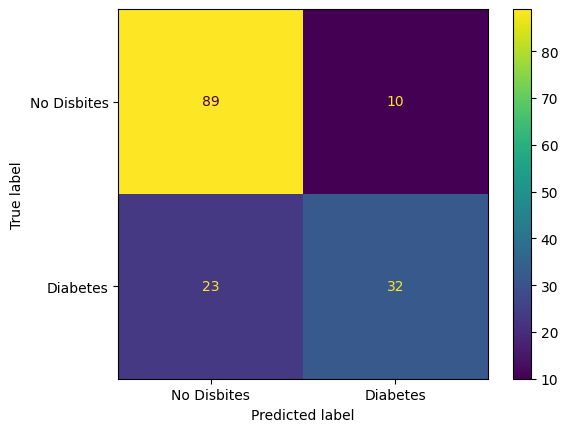

In [29]:
import matplotlib.pyplot as plt
from sklearn import metrics 
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Disbites","Diabetes"])
cm_disp.plot()
plt.show()

In [30]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


In [32]:
Model_Accuracy=(TP+TN)/(TP+FP+FN+TN)
print(f"Accuracy Score :",Model_Accuracy)

Accuracy Score : 0.7857142857142857


[np.float64(0.7207792207792207), np.float64(0.7272727272727273), np.float64(0.7402597402597403), np.float64(0.7207792207792207), np.float64(0.7337662337662337), np.float64(0.7727272727272727), np.float64(0.7597402597402597), np.float64(0.7662337662337663), np.float64(0.7662337662337663), np.float64(0.7597402597402597), np.float64(0.7467532467532467), np.float64(0.7727272727272727), np.float64(0.7662337662337663), np.float64(0.7727272727272727), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7727272727272727), np.float64(0.7727272727272727), np.float64(0.7727272727272727), np.float64(0.7662337662337663), np.float64(0.7727272727272727), np.float64(0.7662337662337663), np.float64(0.7792207792207793), np.float64(0.7532467532467533), np.float64(0.7727272727272727), np.float64(0.7532467532467533), np.float64(0.7662337662337663), np.float64(0.7662337662337663)]


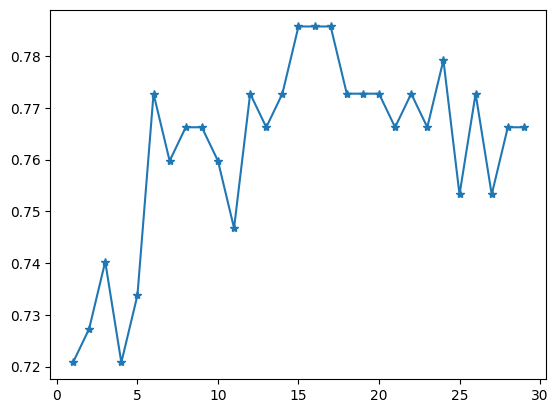

In [73]:
# Test different K values to find maximum accuracy
accuracies = []
k_values = range(1, 30)

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(x_train, y_train)
    prediction_k = model_k.predict(x_test)
    
    cm_k = confusion_matrix(y_test, prediction_k)
    tn = cm_k[0][0]
    fp = cm_k[0][1]
    fn = cm_k[1][0]
    tp = cm_k[1][1]
    
    accuracy_k = (tp + tn) / (tp + tn + fp + fn)
    accuracies.append(accuracy_k)

print(accuracies) # in-class 
plt.plot(range(1, 30), accuracies,marker="*") # in-class
plt.show()
# Find K with maximum accuracy
# max_accuracy = max(accuracies)
# optimal_k = list(k_values)[accuracies.index(max_accuracy)]

# print(f"Optimal K: {optimal_k}")
# print(f"Maximum Accuracy: {max_accuracy*100:.2f}%")


#jbxjb

# Error rate

In [65]:
from sklearn.metrics import accuracy_score
error_rate=1-(accuracy_score(y_test,prediction))
print("error rate",error_rate)

error rate 0.2142857142857143


In [66]:
error_rate1 = (fp + fn) / (tp + tn + fp + fn)
print(error_rate1)

0.21428571428571427


# Sensitivity

In [67]:
print("Sensitivity :",(tp)/(tp+fn))

Sensitivity : 0.5818181818181818


In [68]:
from  sklearn.metrics import recall_score
print("sensitivity :",recall_score(y_test,prediction))

sensitivity : 0.5818181818181818


# Specificity

In [69]:
print("Specificity:",(tn)/(tn+fp))

Specificity: 0.898989898989899


In [70]:
from  sklearn.metrics import recall_score
print("specificity :",recall_score(y_test,prediction,pos_label=0))

specificity : 0.898989898989899


# Precision score

In [71]:
print("Precision:",(tp)/(tp+fp))

Precision: 0.7619047619047619


In [72]:
from  sklearn.metrics import precision_score
print("specificity :",precision_score(y_test,prediction))

specificity : 0.7619047619047619
